In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def draw_angle_arc(ax, vec1, vec2, radius=0.2, center=np.array([0, 0, 0]), n=100, color='magenta'):
    v1 = vec1 / np.linalg.norm(vec1)
    v2 = vec2 / np.linalg.norm(vec2)
    angle = np.arccos(np.clip(np.dot(v1, v2), -1, 1))
    axis = np.cross(v1, v2)
    axis = axis / np.linalg.norm(axis) if np.linalg.norm(axis) != 0 else np.array([0, 0, 1])
    u = v1
    v = np.cross(axis, u)
    theta = np.linspace(0, angle, n)
    arc = np.array([center + radius * (np.cos(t) * u + np.sin(t) * v) for t in theta])
    ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color=color, linewidth=1.5)

def draw_local_axes(ax, origin, scale=0.15, extra_direction=None):
    x_local = origin + scale * np.array([1, 0, 0])
    y_local = origin + scale * np.array([0, 1, 0])
    z_local = origin + scale 
    if extra_direction is None:
        extra_direction = np.array([0, 1, 1])
    extra_direction = extra_direction / np.linalg.norm(extra_direction)
    extra_vec = origin + scale * extra_direction
    ax.quiver(*origin, *(x_local - origin), color='red', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(y_local - origin), color='orange', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(z_local - origin), color='purple', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(extra_vec - origin), color='brown', arrow_length_ratio=0.2, linewidth=1)
    ax.scatter(*origin, color='black', s=10)


def draw_local_axes(ax, origin, scale=0.15, extra_direction=None):
    x_local = origin + scale * np.array([1, 0, 0])
    y_local = origin + scale * np.array([0, 1, 0])
    z_local = origin + scale * np.array([0, 0, 1])
    if extra_direction is None:
        extra_direction = np.array([0, 1, 1])
    extra_direction = extra_direction / np.linalg.norm(extra_direction)
    extra_vec = origin + scale * extra_direction
    ax.quiver(*origin, *(x_local - origin), color='red', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(y_local - origin), color='orange', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(z_local - origin), color='purple', arrow_length_ratio=0.2, linewidth=1)
    ax.quiver(*origin, *(extra_vec - origin), color='brown', arrow_length_ratio=0.2, linewidth=1)
    ax.scatter(*origin, color='black', s=10)


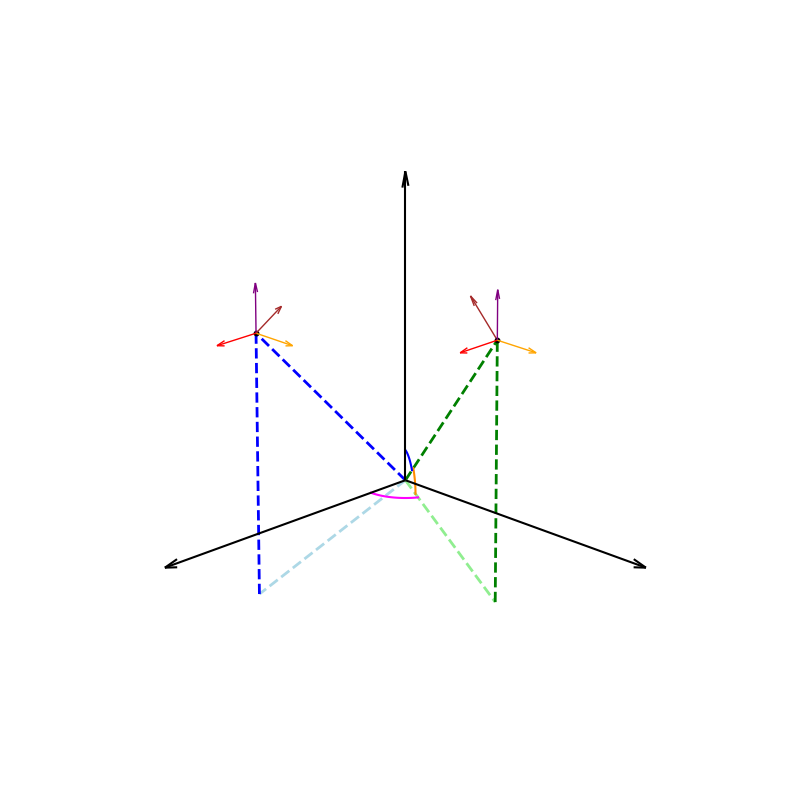

In [9]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')


ax.quiver(0, 0, 0, 1, 0, 0, color='black', arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 1, 0, color='black', arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, 1, color='black', arrow_length_ratio=0.05)


r = 1
z = 0.8

# Vetor A: ângulo 20°
angle_a = np.deg2rad(20)
a = np.array([r * np.cos(angle_a), r * np.sin(angle_a), z])

# Vetor B: ângulo 60°
angle_b = np.deg2rad(60)
b = np.array([r * np.cos(angle_b), r * np.sin(angle_b), z])

# Projeção de B no plano XY
b_proj = np.array([b[0], b[1], 0])


ax.plot([0, a[0]], [0, a[1]], [0, a[2]], 'b--', linewidth=2)
ax.plot([0, b[0]], [0, b[1]], [0, b[2]], 'g--', linewidth=2)


ax.plot([0, a[0]], [0, a[1]], [0, 0], color='lightblue', linestyle='--', linewidth=2)
ax.plot([0, b[0]], [0, b[1]], [0, 0], color='lightgreen', linestyle='--', linewidth=2)


ax.plot([a[0], a[0]], [a[1], a[1]], [0, a[2]], color='blue', linestyle='--', linewidth=2)
ax.plot([b[0], b[0]], [b[1], b[1]], [0, b[2]], color='green', linestyle='--', linewidth=2)


# 1. Ângulo entre vetor B e eixo X (no plano XY)
draw_angle_arc(ax,np.array([1, 0, 0]), b_proj, radius=0.15, color='magenta')

# 2. Ângulo entre projeção de B e o vetor B
draw_angle_arc(ax,b_proj, b, radius=0.12, color='darkorange')

# 3. Ângulo entre vetor B e eixo Z
draw_angle_arc(ax,np.array([0, 0, 1]), b, radius=0.1, color='blue')

draw_local_axes(ax,a)
draw_local_axes(ax, b, extra_direction=np.array([0, -1, 1]))


ax.set_xlim([0, 1.3])
ax.set_ylim([0, 1.3])
ax.set_zlim([0, 1.3])
ax.view_init(elev=20, azim=45)
ax.axis('off')
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

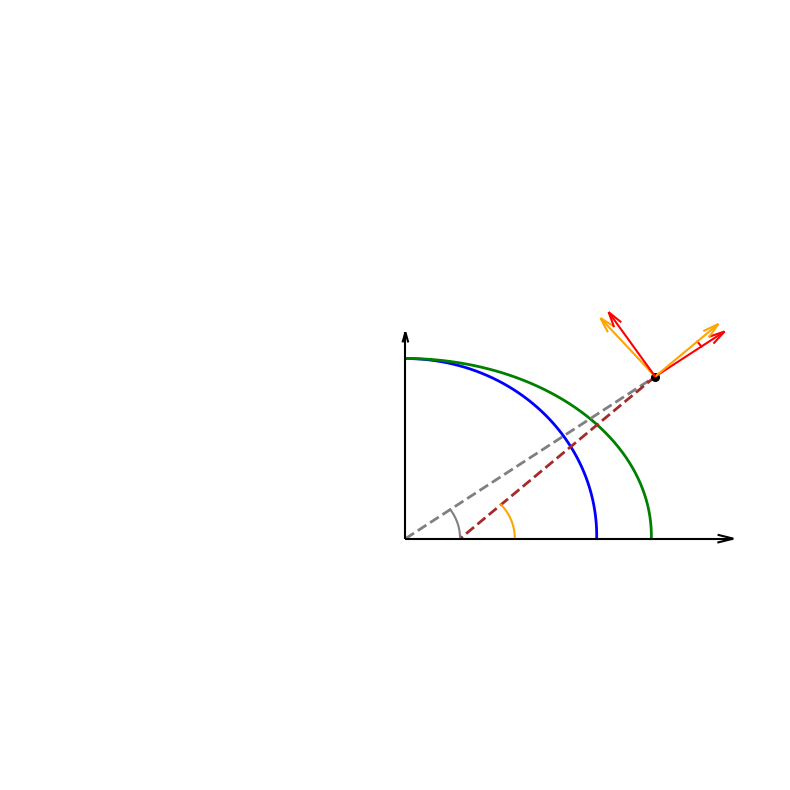

In [4]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')


# --- Eixos principais ---
ax.quiver(0, 0, 0, 1.2, 0, 0, color='black', arrow_length_ratio=0.05)  # eixo X
ax.quiver(0, 0, 0, 0, 0, 0.8, color='black', arrow_length_ratio=0.05)  # eixo Z

# --- Parâmetros para círculo e elipse ---
r = 0.7
theta = np.linspace(0, np.pi/2, 200)

# Círculo no plano XZ (Y=0)
x_circle = r * np.cos(theta)
z_circle = r * np.sin(theta)
ax.plot(x_circle, np.zeros_like(x_circle), z_circle, color='blue', linewidth=2)

# Elipse no plano XZ com a=1, b=0.6
a = 0.9
b = 0.7
x_ellipse = a * np.cos(theta)
z_ellipse = b * np.sin(theta)
ax.plot(x_ellipse, np.zeros_like(x_ellipse), z_ellipse, color='green', linewidth=2)

# --- Ponto fora da elipse e círculo ---
angle_deg = 35
angle = np.deg2rad(angle_deg)

scale_out = 1.1
px = scale_out * np.cos(angle)
pz = scale_out * np.sin(angle)
point = np.array([px, 0, pz])

# Linha até o ponto (tracejada e contínua na base)
ax.plot([0, px], [0, 0], [0, pz], linestyle='--', color='gray', linewidth=2)
spherical =  np.array([0 - px, 0, 0 - pz])


# --- Vetor radial no ponto (vermelho) ---
radial = point
radial_unit = radial / np.linalg.norm(radial)
scale_vec = 0.3
ax.quiver(px, 0, pz, *(scale_vec * radial_unit), color='red', arrow_length_ratio=0.2)

# Vetor ortogonal ao radial (no plano XZ)
orthogonal_radial = np.array([-radial_unit[2], 0, radial_unit[0]])
ax.quiver(px, 0, pz, *(scale_vec * orthogonal_radial), color='red', arrow_length_ratio=0.2)

# --- Normal da elipse no ponto ---
dx = a * np.cos(angle)
dz = b * np.sin(angle)
nx = dx / a**2
nz = dz / b**2
normal_ellipse = np.array([nx, 0, nz])
normal_ellipse_unit = normal_ellipse / np.linalg.norm(normal_ellipse)

# Interseção da normal com o plano z=0
t_intersect = -pz / normal_ellipse_unit[2]
intersect_point = point + t_intersect * normal_ellipse_unit

# Segmento da normal da elipse até o eixo X
ax.plot([px, intersect_point[0]], [0, 0], [pz, intersect_point[2]], color='brown', linestyle='--', linewidth=2)
geodetic =  np.array([intersect_point[0] - px, 0, intersect_point[2] - pz])


# Vetor normal invertido (laranja)
normal_vec = intersect_point - point
normal_unit = normal_vec / np.linalg.norm(normal_vec)
scale_normal = 0.3
ax.quiver(px, 0, pz, *(-scale_normal * normal_unit), color='orange', arrow_length_ratio=0.2)
orthogonal_to_normal = np.array([normal_unit[2], 0, -normal_unit[0]])
ax.quiver(px, 0, pz, *(scale_normal * orthogonal_to_normal), color='orange', arrow_length_ratio=0.2)

# Ponto fora da elipse
ax.scatter(px, 0, pz, color='black', s=30)

# --- Desenho dos ângulos com arcos ---
draw_angle_arc(ax,-geodetic, np.array([1, 0, 0]),  radius=0.2, center=np.array([intersect_point[0], 0, 0]), color='orange')
draw_angle_arc(ax,-spherical, np.array([1, 0, 0]),  radius=0.2, center=np.array([0, 0, 0]), color='gray')
draw_angle_arc(ax,radial_unit, -normal_unit, radius=0.2, center=point, color='red')


ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-0.5, 0.5)
ax.set_zlim(0, 1.2)
ax.view_init(elev=20, azim=-90)
ax.axis('off')
ax.set_aspect("equal")
plt.tight_layout()
plt.show()